In [2]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D


# Load preclinical studies

In [3]:
PRECLINICAL_ANNOTATIONS_PATH = "/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/04_normalization/data/mapped_all/entities_drug_disease_preclin.csv"
preclin_data = pd.read_csv(PRECLINICAL_ANNOTATIONS_PATH)
preclin_data = preclin_data.drop_duplicates(subset=["PMID"])
preclin_data.shape

(540999, 14)

In [4]:
preclin_data

,PMID,unique_conditions_linkbert_predictions,disease_mondo_term_norm,disease_mondo_termid,disease_term_mondo_clean,nearest_dataset_parent_label,merged_mondo_label,merged_mondo_termid,unique_interventions_linkbert_predictions,drug_umls_term_norm,drug_umls_termid,nearest_dataset_parent_umls_label,merged_umls_label,merged_umls_termid
0,31733831,asthma,asthma,MONDO:0004979,asthma,-1,asthma,MONDO:0004979,isorhynchophylline,isorhynchophylline,C0245133,-1,isorhynchophylline,C0245133
1,31733833,myocardial infarction,myocardial infarction,MONDO:0005068,myocardial infarction,-1,myocardial infarction,MONDO:0005068,mir-1192|antgomir-1192|agomir-1192,"MIRN1192 microRNA, mouse|antgomir-1192|agomir-...",C3849422|-1|-1,-1,"MIRN1192 microRNA, mouse|antgomir-1192|agomir-...",C3849422|-1|-1
2,31733925,systemic lupus erythematosus,systemic lupus erythematosus,MONDO:0007915,systemic lupus erythematosus,-1,systemic lupus erythematosus,MONDO:0007915,hla-g2|g2,HLA-G2 Isoform|g2,C0967254|-1,-1,HLA-G2 Isoform|g2,C0967254|-1
3,31733940,cognitive impairment,cognitive disorder,MONDO:0002039,cognitive disorder,-1,cognitive disorder,MONDO:0002039,minocycline,Minocycline,C0026187,-1,Minocycline,C0026187
4,31734027,cumulative peripheral neuropathy|oxaliplatin-i...,cumulative peripheral neuropathy|oxaliplatin-i...,-1|-1|MONDO:0003620,cumulative peripheral neuropathy|oxaliplatin-i...,-1,cumulative peripheral neuropathy|oxaliplatin-i...,-1|-1|MONDO:0003620,tadalafil|phosphodiesterase type 5 inhibitor t...,Tadalafil|Tadalafil,C1176316|C1176316,-1,Tadalafil,C1176316
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540994,57667,leukemia virus,leukemia virus,-1,leukemia virus,-1,leukemia virus,-1,interferon,Interferon,C0021747,-1,Interferon,C0021747
540995,57929,allergic contact dermatitis,allergic contact dermatitis,MONDO:0006525,allergic contact dermatitis,-1,allergic contact dermatitis,MONDO:0006525,cy|cyclophosphamide,cy|Cyclophosphamide,-1|C0010583,-1,cy|Cyclophosphamide,-1|C0010583
540996,58073,rous sarcoma virus,"sarcoma, avian",MONDO:0025382,"sarcoma, avian",-1,"sarcoma, avian",MONDO:0025382,rifazone-82|rifamycin derivative|rifamycin,rifazone-82|Rifamycins|Rifamycin SV,C0073375|C0035609|C0073371,-1,rifazone-82|Rifamycins|Rifamycin SV,C0073375|C0035609|C0073371
540997,58789,acute myocardial ischemia|myocardial ischemia,acute myocardial infarction|myocardial ischemia,MONDO:0004781|MONDO:0024644,acute myocardial infarction|myocardial ischemia,-1|-1,acute myocardial infarction|myocardial ischemia,MONDO:0004781|MONDO:0024644,diethyphen|octadine|papaverine|euphylline,diethyphen|Guanethidine|Papaverine|Euphylline,-1|C0018318|C0030350|C0700954,-1,diethyphen|Guanethidine|Papaverine|Euphylline,-1|C0018318|C0030350|C0700954


In [5]:
PRECLINICAL_METADATA_PATH = "/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/02_animal_study_classification/data/animal_studies/full_pubmed_filtered_animal_6002827_metadata.csv" #"/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/03_IE_ner/data/animal_studies_with_drug_disease/animal_studies_metadata_595768.csv"
metadata_df_year = pd.read_csv(PRECLINICAL_METADATA_PATH)[['PMID','year']]
metadata_df_year = metadata_df_year.drop_duplicates(subset=['PMID'])

preclin_data = preclin_data.merge(metadata_df_year, on="PMID", how="left")

# FDA Clean Neuro NMA

In [6]:
def wrap_drug_label(name: str, max_len: int = 25) -> str:
    """
    Wrap long drug labels onto two lines for plotting.
    - If there's a '|' (e.g. 'Drug | Disease'), split there.
    - Otherwise, break at the nearest space around the middle.
    """
    if not isinstance(name, str):
        return name

    name = name.strip()

    # Prefer splitting at '|'
    if "|" in name:
        left, right = name.split("|", 1)
        return left.strip() + "\n" + right.strip()

    # If it's short enough, keep as is
    if len(name) <= max_len:
        return name

    # Find a space near the middle to break on
    mid = len(name) // 2
    # Look left then right for a space
    break_pos = None
    for offset in range(0, mid):
        left = mid - offset
        right = mid + offset
        if left > 0 and name[left] == " ":
            break_pos = left
            break
        if right < len(name) and name[right] == " ":
            break_pos = right
            break

    if break_pos is None:
        # No space found, hard break
        break_pos = mid

    return name[:break_pos].rstrip() + "\n" + name[break_pos:].lstrip()


In [52]:
def plot_drug_year_bubbles_from_wide_with_extra_studies(
    drug_years: dict,
    earliest_phase_years: dict,
    wide_df: pd.DataFrame,             # rows=drug names, cols=years (int/str) and maybe 'Total'
    title: str = "Timeline of studies for drugs",
    extra_studies_df: pd.DataFrame | None = None,  # other timeline that is not filtered for any disease
    output_file: str | None = None,
    drugs_custom_order: list | None = None,
    year_range: tuple[int, int] | None = None,
    scale: int = 40
):
    """
    Plot a bubble timeline using a wide table of unique-PMID counts per drug-year.
    - Includes drugs even if approval year is missing; approval marker drawn only when available.
    """

    # 1) Detect year columns
    year_cols = []
    for c in wide_df.columns:
        try:
            y = int(c)
            year_cols.append(y)
        except (TypeError, ValueError):
            pass
    year_cols = sorted(set(year_cols))
    if not year_cols:
        raise ValueError("No year columns detected in `wide_df` (columns must be years or castable to int).")

    if year_range:
        y0, y1 = year_range
        year_cols = [y for y in year_cols if y0 <= y <= y1]

    # Ensure numeric counts, fill NaNs
    for y in year_cols:
        wide_df = wide_df.copy()
        wide_df[y] = pd.to_numeric(wide_df.get(y, 0), errors="coerce").fillna(0).astype(int)

    # Do the same for extra_studies_df if provided
    if extra_studies_df is not None:
        extra_studies_df = extra_studies_df.copy()  # avoid chained-assign issues
        for y in year_cols:
            col = extra_studies_df[y] if y in extra_studies_df.columns else pd.Series(0, index=extra_studies_df.index)
            extra_studies_df.loc[:, y] = (
                pd.to_numeric(col, errors="coerce")
                .fillna(0)
                .astype(int)
            )
            
    # 2) Choose drugs to plot (use custom order if given; else all index)
    if drugs_custom_order:
        drugs_in_order = [d for d in drugs_custom_order if d in wide_df.index]
    else:
        drugs_in_order = list(wide_df.index)

    n_drugs = len(drugs_in_order)
    print(f"Plotting {n_drugs} drugs")
    if n_drugs == 0:
        raise ValueError("No drugs to plot (check `wide_df.index` and/or `drugs_custom_order`).")

    # 3) Figure and axes
    fig_height = max(4, 0.75 * n_drugs)
    plt.figure(figsize=(14, 10))
    ax = plt.gca()

    COLOR_PAIR = "#56B4E9"
    COLOR_FDA = "#D55E00"
    COLOR_TRIAL = "#E69F00"
    # 4) Plot per drug (top-to-bottom)
    for i, drug in enumerate(drugs_in_order):
        y_pos = n_drugs - 1 - i
        row = wide_df.loc[drug, year_cols]

        nonzero = row[row > 0]
        if nonzero.empty:
            continue

        # Bubbles
        ax.scatter(
            nonzero.index.astype(int),
            np.full(len(nonzero), y_pos),
            s=(nonzero.values * scale),
            color=COLOR_PAIR,
            alpha=0.7,
            zorder=2,
        )

        # ALL STUDIES FOR THIS DRUG
        if extra_studies_df is not None:
            if "|" in drug:
                drug_lookup, disease = drug.split("|")
                drug_lookup = drug_lookup.strip()
            alias = {"Fampridine": "Dalfampridine"}  # any aliases you need
            drug_extra = alias.get(drug_lookup, drug_lookup)
            
            # get per-year series (ensure missing → 0)
            disease_row = wide_df.loc[drug, year_cols] if drug in wide_df.index else pd.Series(0, index=year_cols)
            extra_studies_df.index = extra_studies_df.index.str.lower()
            drug_key = drug_extra.lower()
            
            extra_row = (
                extra_studies_df.loc[drug_key, year_cols]
                if drug_key in extra_studies_df.index
                else pd.Series(0, index=year_cols)
            )
            resid = (extra_row - disease_row).clip(lower=0)  # no negatives
            nonzero_resid = resid[resid > 0]
            if not nonzero_resid.empty:
                ax.scatter(
                    nonzero_resid.index.astype(int),
                    np.full(len(nonzero_resid), y_pos),
                    s=(nonzero_resid.values * scale),
                    alpha=0.1,
                    color="grey",
                    edgecolor="black",
                    linewidth=0.4,
                    zorder=1,
                )
        

        # Labels on bubbles
        for yr, n in nonzero.items():
            ax.text(int(yr), y_pos, int(n), ha="center", va="center", fontsize=8, zorder=3)

       # Earliest clinical marker ONLY if available and valid
        earliest_phase_year = earliest_phase_years.get(drug, None)
        if earliest_phase_year:
            try:
                ay = int(earliest_phase_year)
                # Thicker dashed line and larger diamond marker in grey
                ax.plot(
                    [ay, ay],
                    [y_pos - 0.4, y_pos + 0.4],
                    linestyle="--",
                    color="grey",
                    linewidth=2.0,
                    alpha=0.8,
                    zorder=3,
                )
                ax.scatter(
                    [ay],
                    [y_pos],
                    marker="D",
                    s=70,            # bigger diamond
                    color=COLOR_TRIAL,
                    edgecolor="black",
                    linewidth=0.5,
                    zorder=5,
                )
            except (TypeError, ValueError):
                pass  # ignore non-int-like values

        # Approval marker ONLY if available and valid
        appr_year = drug_years.get(drug, None)
        if appr_year:
            try:
                ay = int(appr_year)
                # Thicker dashed line and larger diamond marker in grey
                ax.plot(
                    [ay, ay],
                    [y_pos - 0.4, y_pos + 0.4],
                    linestyle="--",
                    color="grey",
                    linewidth=2.0,
                    alpha=0.8,
                    zorder=3,
                )
                ax.scatter(
                    [ay],
                    [y_pos],
                    marker="D",
                    s=70,            # bigger diamond
                    color=COLOR_FDA,
                    edgecolor="black",
                    linewidth=0.5,
                    zorder=5,
                )
            except (TypeError, ValueError):
                pass  # ignore non-int-like values

    # 5) Axis styling
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    
    ax.set_yticks(range(n_drugs))
    wrapped_labels = [wrap_drug_label(d) for d in reversed(drugs_in_order)]

    ax.set_ylim(-1, n_drugs)
    ax.set_xlim(min(year_cols) - 0.5, max(year_cols) + 0.5)
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)

    legend_elements = [
    Line2D([0], [0],
           marker='o', linestyle='None',
           markerfacecolor=COLOR_PAIR, markeredgecolor='black',
           markersize=10,
           label='Animal studies'),
    Line2D([0], [0],
           marker='D', linestyle='None',
           markerfacecolor=COLOR_TRIAL, markeredgecolor='black',
           markersize=8, label='Earliest clinical trial'),
    Line2D([0], [0],
           marker='D', linestyle='None',
           markerfacecolor=COLOR_FDA, markeredgecolor='black',
           markersize=8, label='FDA approval year'),
    
    ]

    # Add this ONLY if extra_studies_df is used (so legend matches the plot)
    if extra_studies_df is not None:
        legend_elements.append(
            Line2D([0], [0],
                   marker='o', linestyle='None',
                   markerfacecolor='grey', markeredgecolor='black',
                   alpha=0.1, markersize=10,
                   label='Animal studies (other disease)')
        )
    titles_labels_font = 22

    ax.legend(handles=legend_elements, fontsize=titles_labels_font-4, loc='lower left', frameon=True)

    plt.xlabel("Publication year", fontsize=titles_labels_font)
    plt.title(title, fontsize=titles_labels_font)
    plt.xticks(fontsize=titles_labels_font)
    plt.yticks(fontsize=titles_labels_font)
    plt.tight_layout()

    if output_file:
        plt.savefig(output_file, dpi=300, bbox_inches="tight")
        print(f"Saved plot to: {output_file}")

    plt.show()

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
from itertools import chain

def plot_diseases_for_drug(df: pd.DataFrame, drug_name: str):
    """
    Given a dataframe and a drug name, this function:
      1. Filters rows where `merged_umls_label` contains the drug name
         (case-insensitive, substring match).
      2. Splits `merged_mondo_label` on '|' to get all associated diseases.
      3. Plots a bar chart of disease frequencies.
      
    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe with at least the columns:
        - 'merged_umls_label'
        - 'merged_mondo_label'
    drug_name : str
        Drug name to look for in `merged_umls_label`.
        
    Returns
    -------
    pd.Series
        A Series with disease names as index and counts as values.
    """
    # 1. Filter rows where merged_umls_label contains the drug name
    mask = df["merged_umls_label"].astype(str).str.contains(drug_name, case=False, na=False)
    df_filtered = df[mask].copy()

    if df_filtered.empty:
        print(f"No rows found with drug name matching '{drug_name}' in 'merged_umls_label'.")
        return pd.Series(dtype=int)

    # 2. Split merged_mondo_label on '|' and flatten
    disease_lists = (
        df_filtered["merged_mondo_label"]
        .dropna()
        .astype(str)
        .str.split("|")
    )

    diseases = list(chain.from_iterable(disease_lists))

    # Clean up disease names (strip spaces, remove empty or '-1')
    diseases = [d.strip() for d in diseases if d and d.strip() and d.strip() != "-1"]

    if not diseases:
        print(f"No valid diseases found in 'merged_mondo_label' for drug '{drug_name}'.")
        return pd.Series(dtype=int)

    # 3. Count frequencies
    disease_counts = pd.Series(diseases).value_counts()
    if len(disease_counts) > 40:
        disease_counts = disease_counts[:20]

    # Plot
    plt.figure(figsize=(10, 5))
    disease_counts.plot(kind="bar")
    plt.title(f"Diseases associated with '{drug_name}'")
    plt.xlabel("Disease (merged_mondo_label)")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    return disease_counts, df_filtered[['PMID','year','unique_conditions_linkbert_predictions', 'merged_mondo_label', 'merged_umls_label']]


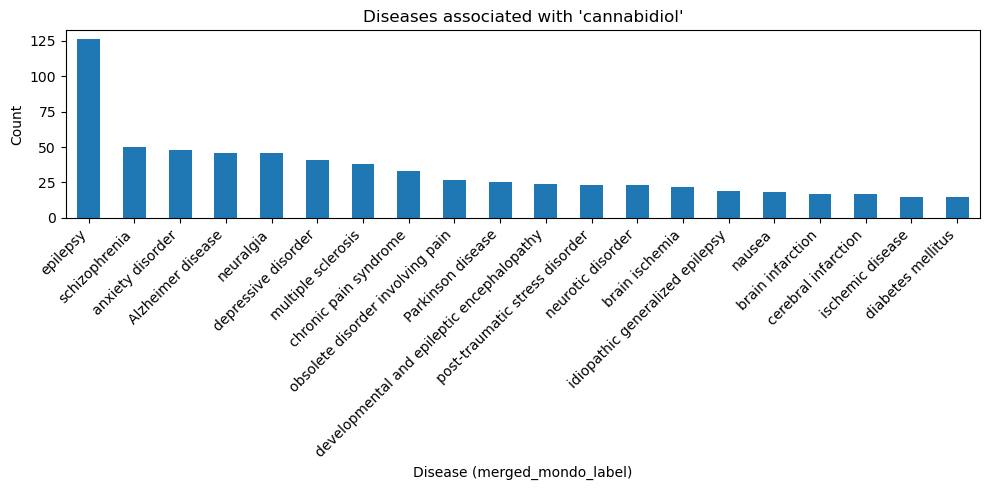

In [9]:
disease_counts, df_filtered = plot_diseases_for_drug(preclin_data, "cannabidiol")

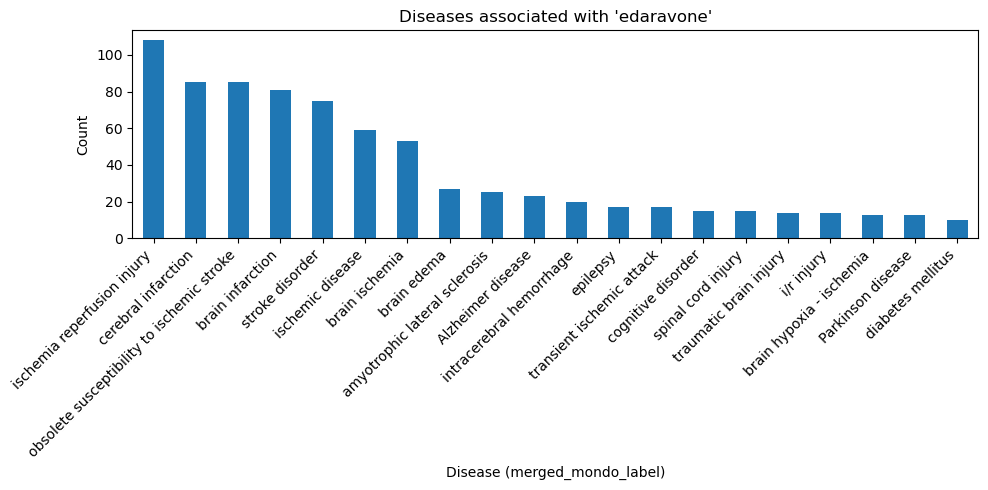

In [10]:
disease_counts, df_filtered = plot_diseases_for_drug(preclin_data, "edaravone")

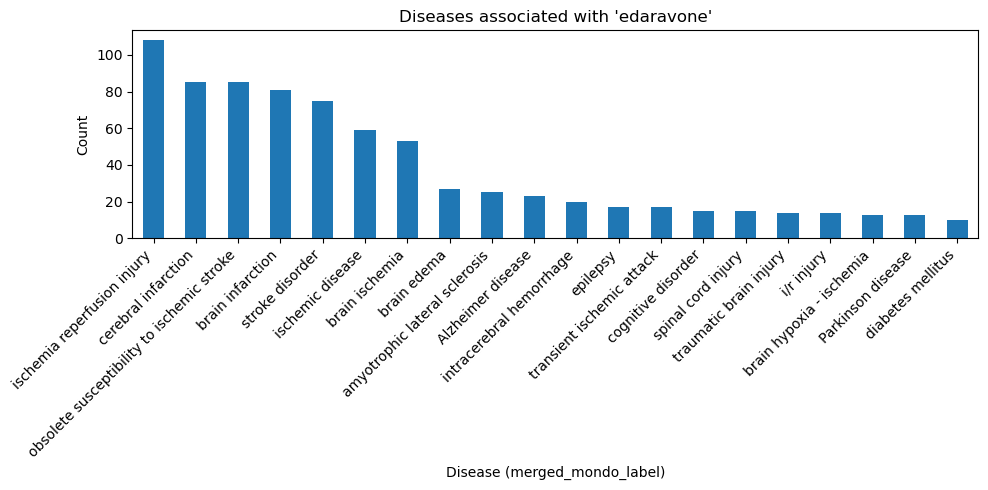

In [11]:
disease_counts, df_filtered = plot_diseases_for_drug(preclin_data, "edaravone")

In [12]:
fda_file = "/scratch/sdonev/Preclinical_Pipeline/10_use_case_disease_focus/out/FDA_neuro_drug_disease_pairs_after_2015_mapped_disease_drug.csv"
df_map = pd.read_csv(fda_file)[['disease','drug','FDA_approval_year','disease_mondo_term_norm','drug_umls_term_norm']]
df_map.head(10)

,disease,drug,FDA_approval_year,disease_mondo_term_norm,drug_umls_term_norm
0,neuromuscular blockade,sugammadex,2015,neuromuscular blockade,Sugammadex
1,venous thromboembolism,edoxaban,2015,venous thromboembolism,edoxaban
2,atrial fibrillation,edoxaban,2015,atrial fibrillation,edoxaban
3,systemic embolism,edoxaban,2015,pulmonary embolism,edoxaban
4,neuroblastoma,dinutuximab,2015,neuroblastoma,Dinutuximab
5,depression,brexpiprazole,2015,depressive disorder,Brexpiprazole
6,stroke,edoxaban,2015,stroke disorder,edoxaban
7,hypoactive sexual desire disorder,flibanserin,2015,hypoactive sexual desire disorder,flibanserin
8,bipolar disorder,cariprazine,2015,bipolar disorder,Cariprazine
9,schizophrenia,cariprazine,2015,schizophrenia,Cariprazine


In [13]:
df_map.shape

(123, 5)

In [14]:
preclin_data.shape

(540999, 15)

In [15]:
preclin_data.head()


,PMID,unique_conditions_linkbert_predictions,disease_mondo_term_norm,disease_mondo_termid,disease_term_mondo_clean,nearest_dataset_parent_label,merged_mondo_label,merged_mondo_termid,unique_interventions_linkbert_predictions,drug_umls_term_norm,drug_umls_termid,nearest_dataset_parent_umls_label,merged_umls_label,merged_umls_termid,year
0,31733831,asthma,asthma,MONDO:0004979,asthma,-1,asthma,MONDO:0004979,isorhynchophylline,isorhynchophylline,C0245133,-1,isorhynchophylline,C0245133,2020.0
1,31733833,myocardial infarction,myocardial infarction,MONDO:0005068,myocardial infarction,-1,myocardial infarction,MONDO:0005068,mir-1192|antgomir-1192|agomir-1192,"MIRN1192 microRNA, mouse|antgomir-1192|agomir-...",C3849422|-1|-1,-1,"MIRN1192 microRNA, mouse|antgomir-1192|agomir-...",C3849422|-1|-1,2020.0
2,31733925,systemic lupus erythematosus,systemic lupus erythematosus,MONDO:0007915,systemic lupus erythematosus,-1,systemic lupus erythematosus,MONDO:0007915,hla-g2|g2,HLA-G2 Isoform|g2,C0967254|-1,-1,HLA-G2 Isoform|g2,C0967254|-1,2020.0
3,31733940,cognitive impairment,cognitive disorder,MONDO:0002039,cognitive disorder,-1,cognitive disorder,MONDO:0002039,minocycline,Minocycline,C0026187,-1,Minocycline,C0026187,2020.0
4,31734027,cumulative peripheral neuropathy|oxaliplatin-i...,cumulative peripheral neuropathy|oxaliplatin-i...,-1|-1|MONDO:0003620,cumulative peripheral neuropathy|oxaliplatin-i...,-1,cumulative peripheral neuropathy|oxaliplatin-i...,-1|-1|MONDO:0003620,tadalafil|phosphodiesterase type 5 inhibitor t...,Tadalafil|Tadalafil,C1176316|C1176316,-1,Tadalafil,C1176316,2019.0


#### generated in Translation_02

In [16]:
disease_col = 'merged_mondo_label'
df_trials = pd.read_csv("data/preclin_dataset_to_clinical.csv")[['PMID', 'drug_term_umls_norm', disease_col , 'n_unique_trials', 'min_phase_nct_id', 'min_phase',
       'min_phase_start_year', 'max_phase_nct_id', 'max_phase', 'earliest_trial_nct_id', 'earliest_trial_phase',
       'earliest_trial_start_year',
       'max_phase_start_year', 'study_classification']]
df_trials = df_trials.merge(metadata_df_year, on="PMID", how="left")

df_trials.head()

,PMID,drug_term_umls_norm,merged_mondo_label,n_unique_trials,min_phase_nct_id,min_phase,min_phase_start_year,max_phase_nct_id,max_phase,earliest_trial_nct_id,earliest_trial_phase,earliest_trial_start_year,max_phase_start_year,study_classification,year
0,157,Lactate,ischemic disease,10.0,NCT04112862,Early Phase 1,2022.0,NCT04488874,Phase 3,NCT00319345,Phase 2/Phase 3,2003.0,2020.0,failed,1975.0
1,2617,Ethanol,hypochromic anemia,24.0,NCT03930446,Early Phase 1,2016.0,NCT02495883,Phase 4,NCT00016679,Phase 1,2001.0,2013.0,approved,1976.0
2,2891,Phenytoin,epilepsy,25.0,NCT01878578,Phase 1,2002.0,NCT00146237,Phase 4,NCT01878578,Phase 1,2002.0,2003.0,approved,1976.0
3,2891,Pentobarbital,epilepsy,3.0,NCT00123578,Phase 1/Phase 2,2004.0,NCT00622570,Phase 3,NCT00622570,Phase 3,2002.0,2002.0,failed,1976.0
4,3420,Propranolol,ventricular arrhythmias due to cardiac ryanodi...,69.0,NCT02871349,Early Phase 1,2016.0,NCT00060866,Phase 4,NCT00236561,Phase 3,2001.0,2003.0,approved,1976.0


In [17]:
df_trials.shape

(325247, 15)

In [18]:
df_trials_exp = (
    df_trials
    .assign(merged_mondo_label=df_trials[disease_col].astype(str).str.split("|"))
    .explode("merged_mondo_label")
)

In [19]:
df_trials_exp.shape

(623532, 15)

In [20]:
df_trials_exp.head()

,PMID,drug_term_umls_norm,merged_mondo_label,n_unique_trials,min_phase_nct_id,min_phase,min_phase_start_year,max_phase_nct_id,max_phase,earliest_trial_nct_id,earliest_trial_phase,earliest_trial_start_year,max_phase_start_year,study_classification,year
0,157,Lactate,ischemic disease,10.0,NCT04112862,Early Phase 1,2022.0,NCT04488874,Phase 3,NCT00319345,Phase 2/Phase 3,2003.0,2020.0,failed,1975.0
1,2617,Ethanol,hypochromic anemia,24.0,NCT03930446,Early Phase 1,2016.0,NCT02495883,Phase 4,NCT00016679,Phase 1,2001.0,2013.0,approved,1976.0
2,2891,Phenytoin,epilepsy,25.0,NCT01878578,Phase 1,2002.0,NCT00146237,Phase 4,NCT01878578,Phase 1,2002.0,2003.0,approved,1976.0
3,2891,Pentobarbital,epilepsy,3.0,NCT00123578,Phase 1/Phase 2,2004.0,NCT00622570,Phase 3,NCT00622570,Phase 3,2002.0,2002.0,failed,1976.0
4,3420,Propranolol,ventricular arrhythmias due to cardiac ryanodi...,69.0,NCT02871349,Early Phase 1,2016.0,NCT00060866,Phase 4,NCT00236561,Phase 3,2001.0,2003.0,approved,1976.0


In [21]:
df_map["disease_clean"] = df_map["disease"].str.strip().str.lower()
df_map["drug_clean"]    = df_map["drug"].str.strip().str.lower()

df_trials_exp["disease_clean"] = df_trials_exp[disease_col].str.strip().str.lower()
df_trials_exp["drug_clean"]    = df_trials_exp["drug_term_umls_norm"].str.strip().str.lower()

# Keep only the (disease, drug) pairs from df_map
pairs = df_map[["disease_clean", "drug_clean"]].drop_duplicates()

df_trials_exp["fda_mapped_disease"] = None


In [22]:
df_trials_exp["fda_mapped_disease"] = None
df_trials_exp["fda_mapped_drug"] = None

for _, row in pairs.iterrows():
    d = row["disease_clean"]    # FDA disease
    dr = row["drug_clean"]      # FDA drug
    
    mask = (
        df_trials_exp["disease_clean"].str.contains(d, case=False, na=False, regex=False) &
        df_trials_exp["drug_clean"].str.contains(dr, case=False, na=False, regex=False)
    )
    
    df_trials_exp.loc[mask, "fda_mapped_disease"] = d
    df_trials_exp.loc[mask, "fda_mapped_drug"] = dr


In [23]:
df_trials_filtered = df_trials_exp.dropna(subset=["fda_mapped_disease", "fda_mapped_drug"])

df_trials_filtered.head()

,PMID,drug_term_umls_norm,merged_mondo_label,n_unique_trials,min_phase_nct_id,min_phase,min_phase_start_year,max_phase_nct_id,max_phase,earliest_trial_nct_id,earliest_trial_phase,earliest_trial_start_year,max_phase_start_year,study_classification,year,disease_clean,drug_clean,fda_mapped_disease,fda_mapped_drug
477,407606,Cannabidiol,childhood absence epilepsy,151.0,NCT04280289,Early Phase 1,2020.0,NCT01964547,Phase 4,NCT01610713,Phase 3,2001.0,2012.0,approved,1977.0,childhood absence epilepsy,cannabidiol,epilepsy,cannabidiol
477,407606,Cannabidiol,childhood-onset idiopathic generalized epileps...,151.0,NCT04280289,Early Phase 1,2020.0,NCT01964547,Phase 4,NCT01610713,Phase 3,2001.0,2012.0,approved,1977.0,childhood-onset idiopathic generalized epileps...,cannabidiol,epilepsy,cannabidiol
5822,2292245,stiripentol,epilepsy with generalized tonic-clonic seizures,2.0,NCT02607891,Phase 2,2016.0,NCT02607891,Phase 2,NCT02607891,Phase 2,2016.0,2016.0,failed,1990.0,epilepsy with generalized tonic-clonic seizures,stiripentol,seizures,stiripentol
7085,2571101,Cannabidiol,epilepsy,151.0,NCT04280289,Early Phase 1,2020.0,NCT01964547,Phase 4,NCT01610713,Phase 3,2001.0,2012.0,approved,1989.0,epilepsy,cannabidiol,epilepsy,cannabidiol
12320,6129147,Cannabidiol,epilepsy,151.0,NCT04280289,Early Phase 1,2020.0,NCT01964547,Phase 4,NCT01610713,Phase 3,2001.0,2012.0,approved,1982.0,epilepsy,cannabidiol,epilepsy,cannabidiol


In [24]:
dis_col_to_use = "fda_mapped_disease"
drug_col_to_use = "fda_mapped_drug"

In [25]:
pair_pmid_counts = (
    df_trials_filtered
    .groupby([drug_col_to_use, dis_col_to_use])["PMID"]
    .nunique()
    .reset_index(name="n_pmids")
    .sort_values("n_pmids", ascending=False)
)
pair_pmid_counts["drug_disease"] = (
    pair_pmid_counts[drug_col_to_use] + " | " + pair_pmid_counts[dis_col_to_use]
)
print(len(pair_pmid_counts))
pair_pmid_counts

43


,fda_mapped_drug,fda_mapped_disease,n_pmids,drug_disease
6,cannabidiol,epilepsy,97,cannabidiol | epilepsy
33,siponimod,multiple sclerosis,26,siponimod | multiple sclerosis
4,brivaracetam,epilepsy,24,brivaracetam | epilepsy
8,cariprazine,schizophrenia,22,cariprazine | schizophrenia
14,edaravone,amyotrophic lateral sclerosis,17,edaravone | amyotrophic lateral sclerosis
3,brexpiprazole,schizophrenia,15,brexpiprazole | schizophrenia
13,deflazacort,duchenne muscular dystrophy,12,deflazacort | duchenne muscular dystrophy
7,cariprazine,bipolar disorder,10,cariprazine | bipolar disorder
31,selumetinib,neurofibromatosis type 1,9,selumetinib | neurofibromatosis type 1
38,sugammadex,neuromuscular blockade,9,sugammadex | neuromuscular blockade


In [26]:
drug_disease_pair_counts = dict(zip(pair_pmid_counts['drug_disease'], pair_pmid_counts['n_pmids']))
pair_pmid_counts_top_10 = pair_pmid_counts.head(10)
pair_pmid_counts_top_10_list = list(pair_pmid_counts_top_10['drug_disease'])

In [27]:
drug_disease_pair_counts

{'cannabidiol | epilepsy': 97,
 'siponimod | multiple sclerosis': 26,
 'brivaracetam | epilepsy': 24,
 'cariprazine | schizophrenia': 22,
 'edaravone | amyotrophic lateral sclerosis': 17,
 'brexpiprazole | schizophrenia': 15,
 'deflazacort | duchenne muscular dystrophy': 12,
 'cariprazine | bipolar disorder': 10,
 'selumetinib | neurofibromatosis type 1': 9,
 'sugammadex | neuromuscular blockade': 9,
 'edoxaban | atrial fibrillation': 8,
 'ganaxolone | seizures': 8,
 'flibanserin | hypoactive sexual desire disorder': 7,
 'pitolisant | narcolepsy': 7,
 'givinostat | duchenne muscular dystrophy': 7,
 'vamorolone | duchenne muscular dystrophy': 7,
 'cenobamate | epilepsy': 7,
 'ozanimod | multiple sclerosis': 6,
 'amifampridine | lambert-eaton myasthenic syndrome': 5,
 'nusinersen | spinal muscular atrophy': 5,
 'lasmiditan | migraine': 5,
 'atogepant | migraine': 5,
 'brexanolone | depression': 5,
 'risdiplam | spinal muscular atrophy': 5,
 'brivaracetam | seizures': 4,
 'rimegepant | mi

In [28]:
df_trials_filtered.PMID.nunique()

345

In [29]:
df_trials_filtered["year"] = (
    df_trials_filtered["year"]
    .astype("Int64")   # safe integer
)
pmid_counts = (
    df_trials_filtered
    .groupby([drug_col_to_use, dis_col_to_use, "year"])["PMID"]
    .nunique()     # count unique PMIDs per year
    .reset_index(name="n_pmids")
)

/tmp/ipykernel_34423/1137319519.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_trials_filtered["year"] = (


In [30]:
pmid_counts

,fda_mapped_drug,fda_mapped_disease,year,n_pmids
0,amifampridine,lambert-eaton myasthenic syndrome,2012,1
1,amifampridine,lambert-eaton myasthenic syndrome,2014,1
2,amifampridine,lambert-eaton myasthenic syndrome,2017,1
3,amifampridine,lambert-eaton myasthenic syndrome,2022,1
4,amifampridine,lambert-eaton myasthenic syndrome,2023,1
...,...,...,...,...
197,vamorolone,duchenne muscular dystrophy,2018,1
198,vamorolone,duchenne muscular dystrophy,2019,1
199,vamorolone,duchenne muscular dystrophy,2021,1
200,vamorolone,duchenne muscular dystrophy,2024,1


In [31]:
pmid_counts["drug_disease"] = (
    pmid_counts[drug_col_to_use] + " | " + pmid_counts[dis_col_to_use]
)

pmid_year_matrix = (
    pmid_counts
    .pivot_table(
        index="drug_disease",   # <-- single index now
        columns="year",
        values="n_pmids",
        fill_value=0
    )
)
# Sort by total PMIDs across all years (row-wise sum), descending
pmid_year_matrix = pmid_year_matrix.loc[
    pmid_year_matrix.sum(axis=1).sort_values(ascending=False).index
]
#pmid_year_matrix["Total"] = pmid_year_matrix.sum(axis=1)
pmid_year_matrix.head()

year,1977,1980,1982,1989,1990,1998,2000,2001,2003,2006,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
drug_disease,,,,,,,,,,,,,,,,,,,,,
cannabidiol | epilepsy,1,1,2,1,0,0,0,1,1,0,...,2,3,4,6,10,14,10,17,16,4
siponimod | multiple sclerosis,0,0,0,0,0,0,0,0,0,0,...,0,2,0,0,1,2,3,9,6,3
brivaracetam | epilepsy,0,0,0,0,0,0,0,0,0,0,...,2,1,2,2,0,1,2,3,4,2
cariprazine | schizophrenia,0,0,0,0,0,0,0,0,0,0,...,0,2,2,4,2,1,1,3,3,0
edaravone | amyotrophic lateral sclerosis,0,0,0,0,0,0,0,0,0,0,...,1,0,0,1,1,3,3,3,2,1


In [32]:
dict_fda_approval_years = {
    (row["drug"].strip().lower(), row["disease"].strip().lower()): int(row["FDA_approval_year"])
    for _, row in df_map.iterrows()
}
len(dict_fda_approval_years)

123

In [33]:
dict_earliest_phase_years = (
    df_trials_filtered
    .groupby([drug_col_to_use, dis_col_to_use])["earliest_trial_start_year"]
    .min()
    .dropna()
    .astype(int)
    .to_dict()
)


In [34]:
valid_keys = set(pmid_year_matrix.index)
dict_fda_approval_years_str = {
    f"{drug} | {disease}": year
    for (drug, disease), year in dict_fda_approval_years.items()
}
dict_earliest_phase_years_str = {
    f"{drug} | {disease}": year
    for (drug, disease), year in dict_earliest_phase_years.items()
}


filtered_drug_years = {
    key: year
    for key, year in dict_fda_approval_years_str.items()
    if key in valid_keys
}

filtered_earliest_phase_years = {
    key: year
    for key, year in dict_earliest_phase_years_str.items()
    if key in valid_keys
}


In [35]:
len(filtered_drug_years), len(filtered_earliest_phase_years)

(43, 43)

In [36]:
# generated in Translation_02
all_drugs_timeline = pd.read_csv("./out/all_drugs_articles_timeline.csv")

In [37]:
all_drugs_timeline.head()

,merged_umls_label,1849,1869,1870,1904,1906,1908,1909,1911,1912,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Total
0,Dexamethasone,0,0,0,0,0,0,0,0,0,...,184,204,210,198,224,225,168,189,9,5801
1,Acetylcysteine,0,0,0,0,0,0,0,0,0,...,199,215,214,228,208,203,192,183,4,4557
2,NG-Nitroarginine Methyl Ester,0,0,0,0,0,0,0,0,0,...,86,85,88,93,65,62,42,35,0,4304
3,Sirolimus,0,0,0,0,0,0,0,0,0,...,221,256,271,295,302,262,228,229,10,4104
4,Doxorubicin,0,0,0,0,0,0,0,0,0,...,190,252,270,252,226,239,218,188,9,4019


In [38]:

def format_wide_to_indexed(
    df: pd.DataFrame,
    name_col: str = "merged_umls_label",
    index_name: str = "unique_drug_target"
) -> pd.DataFrame:
    out = df.copy()

    # Convert year-like columns to ints (keep 'Total' as-is)
    year_like = [c for c in out.columns if c not in [name_col, "Total"]]
    col_map = {}
    for c in year_like:
        try:
            col_map[c] = int(c)
        except (ValueError, TypeError):
            pass  # ignore non-year extras
    out = out.rename(columns=col_map)

    # Set index to drug name
    out = out.set_index(name_col)
    out.index.name = index_name

    # Determine ordered year columns
    year_cols = sorted([c for c in out.columns if isinstance(c, int)])

    # Ensure numeric and integer dtype
    out[year_cols] = out[year_cols].apply(pd.to_numeric, errors="coerce").fillna(0).astype(int)

    # Add/position Total at the end
    if "Total" not in out.columns:
        out["Total"] = out[year_cols].sum(axis=1)
    else:
        out["Total"] = pd.to_numeric(out["Total"], errors="coerce").fillna(0).astype(int)

    out = out[year_cols + ["Total"]]

    # Name the columns axis as 'year'
    out.columns.name = "year"
    return out
    
all_drugs_timeline = format_wide_to_indexed(all_drugs_timeline)


In [39]:
all_drugs_timeline.head()

year,1849,1869,1870,1904,1906,1908,1909,1911,1912,1913,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Total
unique_drug_target,,,,,,,,,,,,,,,,,,,,,
Dexamethasone,0,0,0,0,0,0,0,0,0,0,...,184,204,210,198,224,225,168,189,9,5801
Acetylcysteine,0,0,0,0,0,0,0,0,0,0,...,199,215,214,228,208,203,192,183,4,4557
NG-Nitroarginine Methyl Ester,0,0,0,0,0,0,0,0,0,0,...,86,85,88,93,65,62,42,35,0,4304
Sirolimus,0,0,0,0,0,0,0,0,0,0,...,221,256,271,295,302,262,228,229,10,4104
Doxorubicin,0,0,0,0,0,0,0,0,0,0,...,190,252,270,252,226,239,218,188,9,4019


In [40]:
filtered_drug_years_top_10 = {k: v for k, v in filtered_drug_years.items() if k in pair_pmid_counts_top_10_list}

In [41]:
filtered_drug_years_top_10

{'sugammadex | neuromuscular blockade': 2015,
 'cariprazine | bipolar disorder': 2015,
 'cariprazine | schizophrenia': 2015,
 'brexpiprazole | schizophrenia': 2015,
 'brivaracetam | epilepsy': 2016,
 'deflazacort | duchenne muscular dystrophy': 2017,
 'edaravone | amyotrophic lateral sclerosis': 2017,
 'cannabidiol | epilepsy': 2018,
 'siponimod | multiple sclerosis': 2019,
 'selumetinib | neurofibromatosis type 1': 2020}

Plotting 10 drugs
Saved plot to: viz/top_10_drug_timeline_preclinical_clinical.pdf


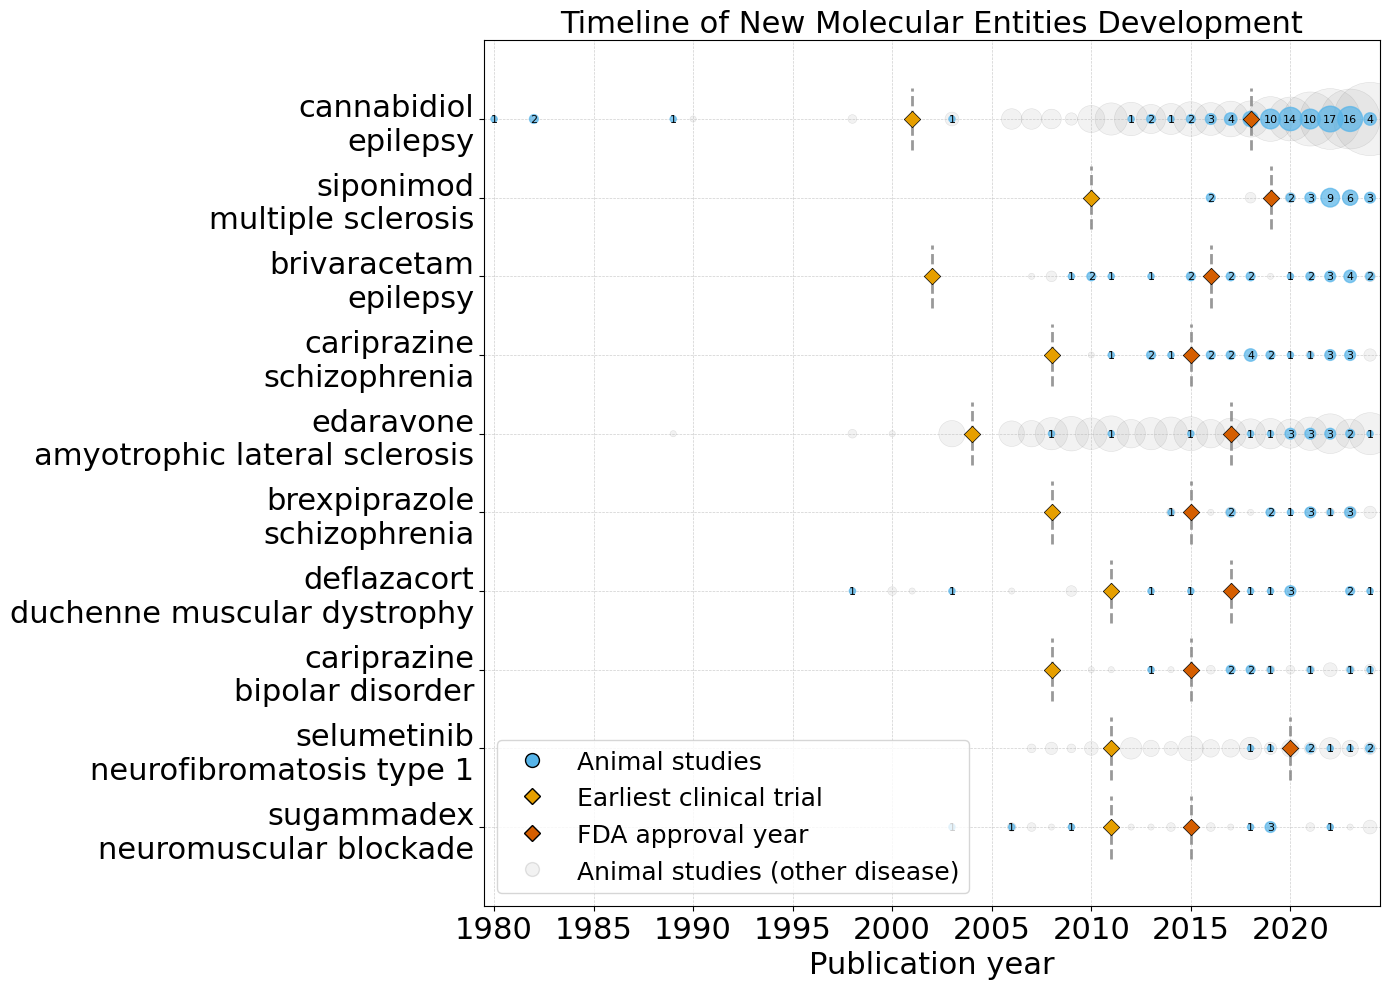

In [53]:
top_n = 10
plot_drug_year_bubbles_from_wide_with_extra_studies(
    drug_years=filtered_drug_years,
    earliest_phase_years=filtered_earliest_phase_years,
    wide_df=pmid_year_matrix.head(top_n),
    title="Timeline of New Molecular Entities Development",
    extra_studies_df=all_drugs_timeline,
    output_file=f"viz/top_{top_n}_drug_timeline_preclinical_clinical.pdf",
    #drugs_custom_order=approved_drugs_list,  # optional
    year_range=(1979, 2024),
    scale=20
)